<a href="https://colab.research.google.com/github/Blenkzx/LINGUAGENS-DE-PROGRAMA-O/blob/main/EXERC%C3%8DCIO_PRATICO_1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Etapa 1: Leitura e Diagnóstico dos Dados

Vamos começar importando as bibliotecas necessárias, carregando o arquivo CSV em um DataFrame e realizando um diagnóstico inicial dos dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega o arquivo streamdata_usuarios.csv em um DataFrame
df_stream = pd.read_csv('/content/streamdata_usuarios.csv')

# Exibe as 5 primeiras linhas do DataFrame
print('Primeiras 5 linhas do DataFrame:')
display(df_stream.head())

# Verifica os tipos de dados das colunas com .info()
print('\nInformações do DataFrame:')
df_stream.info()

Primeiras 5 linhas do DataFrame:


,id_usuario,plano,horas_assistidas,dispositivo_principal,score_satisfacao,cancelou_assinatura
0,USR-0001,Básico,17.5,Smart TV,5,Não
1,USR-0002,Padrão,21.3,Smartphone,4,Não
2,USR-0003,Premium,23.9,Tablet,4,Não
3,USR-0004,Básico,53.2,Smart TV,7,Não
4,USR-0005,Padrão,61.7,Tablet,5,Sim



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_usuario             250 non-null    object 
 1   plano                  250 non-null    object 
 2   horas_assistidas       250 non-null    float64
 3   dispositivo_principal  250 non-null    object 
 4   score_satisfacao       250 non-null    int64  
 5   cancelou_assinatura    250 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 11.8+ KB


## Etapa 2: Média de Horas Assistidas por Plano (Gráfico de Barras Horizontal)

Agora, vamos identificar qual plano de assinatura consome mais horas de conteúdo por mês, agrupando os dados e criando um gráfico de barras horizontal.

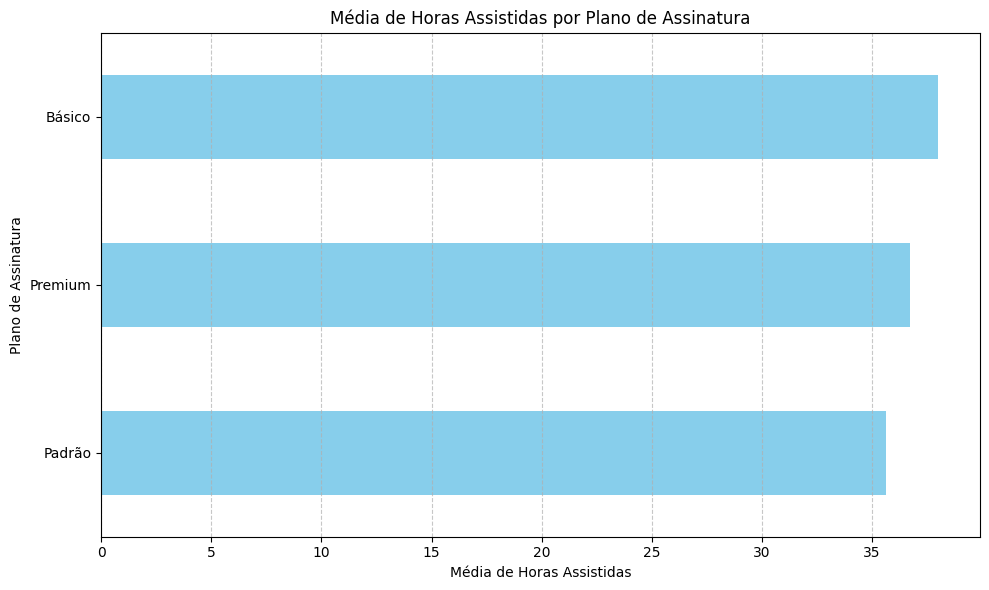

In [2]:
# Agrupa o DataFrame por plano e calcula a média de horas_assistidas
media_horas_por_plano = df_stream.groupby('plano')['horas_assistidas'].mean().sort_values(ascending=True)

# Cria o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
media_horas_por_plano.plot(kind='barh', color='skyblue')
plt.xlabel('Média de Horas Assistidas')
plt.ylabel('Plano de Assinatura')
plt.title('Média de Horas Assistidas por Plano de Assinatura')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Etapa 3: Relação entre Satisfação e Cancelamento (Histogramas Comparativos)

Vamos investigar se existe uma relação entre o score de satisfação dos usuários e a decisão de cancelar a assinatura, utilizando histogramas sobrepostos.

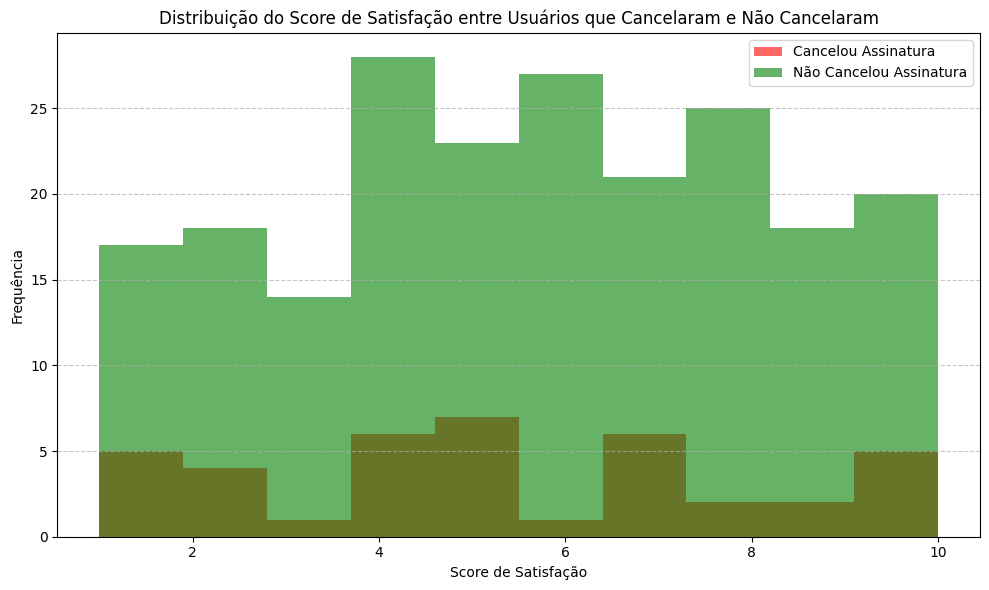

In [3]:
# Filtra os usuários em dois grupos
cancelou = df_stream[df_stream['cancelou_assinatura'] == 'Sim']['score_satisfacao']
nao_cancelou = df_stream[df_stream['cancelou_assinatura'] == 'Não']['score_satisfacao']

# Cria o gráfico com dois histogramas sobrepostos
plt.figure(figsize=(10, 6))
plt.hist(cancelou, bins=10, alpha=0.6, label='Cancelou Assinatura', color='red')
plt.hist(nao_cancelou, bins=10, alpha=0.6, label='Não Cancelou Assinatura', color='green')
plt.xlabel('Score de Satisfação')
plt.ylabel('Frequência')
plt.title('Distribuição do Score de Satisfação entre Usuários que Cancelaram e Não Cancelaram')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Etapa 4: Distribuição dos Dispositivos Principais (Gráfico de Pizza/Rosca)

Por fim, vamos identificar os dispositivos mais utilizados pelos assinantes para auxiliar no planejamento de desenvolvimento, usando um gráfico de pizza.

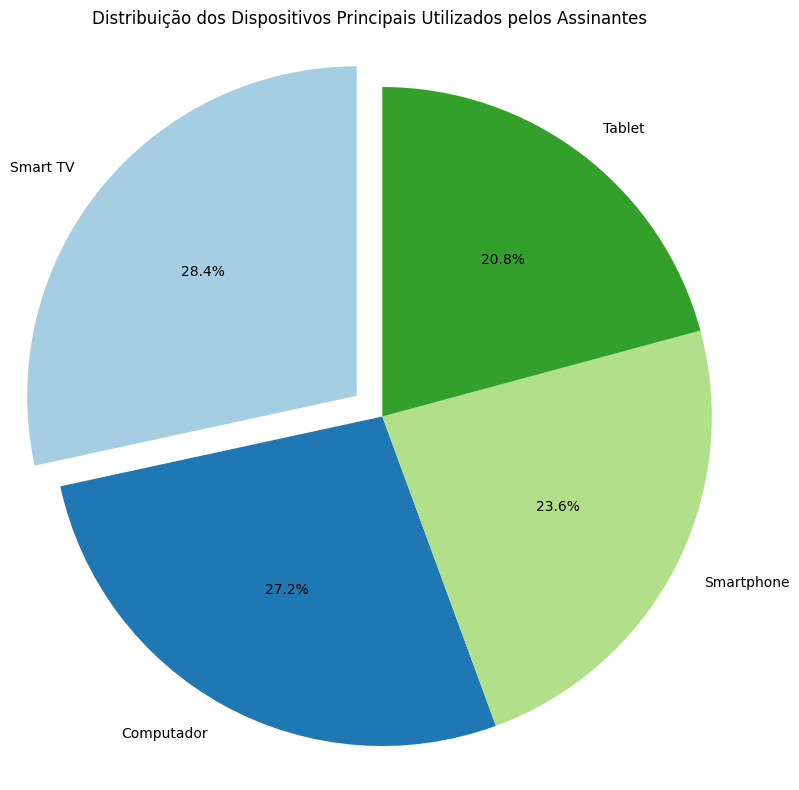

In [4]:
# Conta o total de usuários por dispositivo_principal
contagem_dispositivos = df_stream['dispositivo_principal'].value_counts()

# Identifica a fatia a ser destacada (o dispositivo mais utilizado)
explode = [0.1 if device == contagem_dispositivos.index[0] else 0 for device in contagem_dispositivos.index]

# Cria o gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(contagem_dispositivos,
        labels=contagem_dispositivos.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode,
        colors=plt.cm.Paired.colors)
plt.title('Distribuição dos Dispositivos Principais Utilizados pelos Assinantes')
plt.axis('equal') # Garante que o gráfico de pizza seja um círculo.
plt.tight_layout()
plt.show()